In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
 #   for filename in filenames:
  #      print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
!pip install torch-snippets==0.499.0
#!pip install torchsummary 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26304 sha256=08d2f095e9fbf52734b4f122d3a6838bde2fe651ae762fb8d24a414b27f1c2be
  Stored in directory: /root/.cache/pip/wheels/7c/d0/9e/1f26ebb66d9e1732e4098bc5a6c2d91f6c9a529838f0284890
Successfully built typing


In [5]:
pip install --upgrade torch_snippets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.2/204.2 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 69.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.6/30.6 MB 57.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: platformdirs
    Found existing installation: platformdirs 4.1.0
    Uninstalling platformdirs-4.1.0:
      Successfully uninstalled platformdirs-4.1.0
  Attempting uninstall: torch_snippets
    Found existing installation: torch-snippets 0.499
    Uninstalling torch-snippets-0.499:
      Successfully uninstalled torch-snippets-0.499
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyterlab 4.0.11 requires jupyter-lsp>=2.0.0, but you 

In [6]:
from torch_snippets import *
from torchvision import transforms
from sklearn.model_selection import train_test_split
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import cv2 
import numpy as np 
import pandas as pd 
import nibabel as nib
import glob 

In [7]:
image_paths=sorted(glob.glob('/kaggle/input/people-clothing-segmentation/png_images/IMAGES/*.png'))
mask_paths=sorted(glob.glob('/kaggle/input/people-clothing-segmentation/png_masks/MASKS/*.png'))

In [8]:
train_images=image_paths[:int(0.8*(len(image_paths)))]
train_labels=mask_paths[:int(0.8*(len(mask_paths)))]
test_images=image_paths[int(0.8*(len(image_paths))):]
test_label=mask_paths[int(0.8*(len(mask_paths))):]

In [9]:
tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # imagenet
])

In [10]:
class SegData(Dataset):
    def __init__(self,images,labels):
        self.images=images
        self.labels=labels
    def __len__(self):
        return len(self.images)
    def __getitem__(self, ix):
        image = cv2.imread(self.images[ix])
        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (512,512))
        mask = read(self.labels[ix],1)
        mask = cv2.resize(mask, (512,512))
        mask=cv2.cvtColor(mask,cv2.COLOR_RGB2GRAY)
        return image, mask
    def choose(self): return self[randint(len(self))]
    def collate_fn(self, batch):
        ims, masks = list(zip(*batch))
        ims = torch.cat([tfms(im.copy()/255.)[None] for im in ims]).float().to(device)
        ce_masks = torch.cat([torch.Tensor(mask)[None] for mask in masks]).long().to(device)
        return ims, ce_masks

In [11]:
train_dataset=SegData(train_images,train_labels)
test_dataset=SegData(test_images,test_label)

(512, 512, 3)

(512, 512)

(512, 512, 3)

44

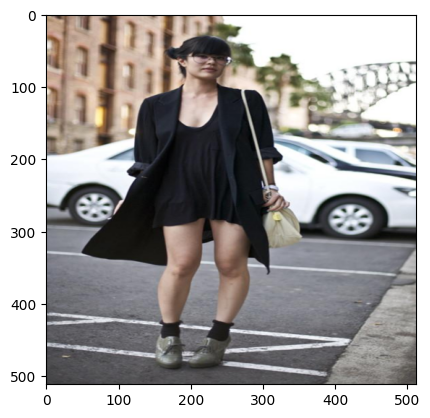

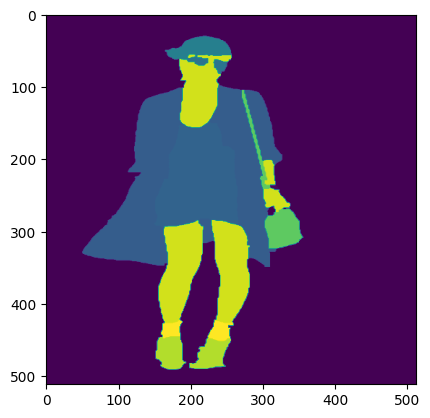

In [12]:
image,mask=train_dataset[10]
print(image.shape)
print(mask.shape)
plt.imshow(image)
plt.figure()
plt.imshow(mask)
print(image.shape)
print(mask.max())

In [13]:
from torch import nn 
import torchvision
import torch.nn.functional as F

In [14]:
def conv(nin,nout,kernel_size):
  return nn.Sequential(
          nn.Conv2d(nin,nout, kernel_size=kernel_size,padding="same"),
          nn.BatchNorm2d(nout),
          nn.ReLU(inplace=True))
  
class resconv(nn.Module):
  def __init__(self,in_features,out_features):
    super(resconv,self).__init__()
    self.block=nn.Sequential(
        nn.ReflectionPad2d(1),
        nn.Conv2d(in_features,out_features,3),
        nn.InstanceNorm2d(out_features),
        nn.ReLU(inplace=True),
        nn.ReflectionPad2d(1),
        nn.Conv2d(out_features,out_features,3),
        nn.InstanceNorm2d(out_features),
        nn.ReLU(inplace=True),
        
    )
  def forward(self,x):
      return x+self.block(x)

def up_conv(nin,nout):
  return nn.Sequential(
      nn.ConvTranspose2d(nin,nout,kernel_size=2,stride=2),
      nn.InstanceNorm2d(nout),
      nn.ReLU(),
  )

In [15]:
class ResUnet1(nn.Module):
  def __init__(self):
    super().__init__()
    self.block1=conv(3,64,(7,7))
    self.max_pool=nn.MaxPool2d(2,stride=2)
    self.block2=conv(64,128,(1,1))
    self.block3=conv(128,256,(1,1))
    self.block4=conv(256,512,(1,1))
    self.block2_1=resconv(64,64)
    self.block3_1=resconv(128,128)
    self.block4_1=resconv(256,256)
    self.block_5_1=resconv(512,512)
    self.upconv5=up_conv(512,512)
    self.upconv4=up_conv(512,256)
    self.upconv3=up_conv(256,128)
    self.upconv2=up_conv(128,64)
    self.conv6=conv(512+512,512,kernel_size=(3,3))
    self.conv5=conv(256+256,256,kernel_size=(3,3))
    self.conv4=conv(128+128,128,kernel_size=(3,3))
    self.conv3=conv(64+64,64,kernel_size=(3,3))
    self.last_conv=nn.Conv2d(64,59,kernel_size=(1,1),padding="same")
  def forward(self,x):
    x1=self.block1(x)
    x2=self.max_pool(x1)
    x3=self.block2_1(x2)
    x4=self.block2(x3)
    x5=self.max_pool(x4)
    x6=self.block3_1(x5)
    x7=self.block3(x6)
    x8=self.max_pool(x7)
    x9=self.block4_1(x8)
    x10=self.block4(x9)
    x11=self.max_pool(x10)
    x12=self.block_5_1(x11)
    y12=self.upconv5(x12)
    y_out1=torch.cat([y12,x10],dim=1)
    y_out1=self.conv6(y_out1)
    y11=self.upconv4(y_out1)
    y_out2=torch.cat([y11,x7],dim=1)
    y_out2=self.conv5(y_out2)
    y10=self.upconv3(y_out2)
    y_out3=torch.cat([y10,x4],dim=1)
    y_out3=self.conv4(y_out3)
    y9=self.upconv2(y_out3)
    y_out=torch.cat([y9,x1],dim=1)
    y_out=self.conv3(y_out)
    out=self.last_conv(y_out)
    return out


In [16]:
model=ResUnet1()
model=model.to(device)


In [17]:
ce = nn.CrossEntropyLoss()
def UnetLoss(preds, targets):
    ce_loss = ce(preds, targets)
    acc = (torch.argmax(preds,1) == targets).float().mean()
    return ce_loss, acc

In [18]:
criterion=UnetLoss
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
scheduler=torch.optim.lr_scheduler.StepLR(optimizer,gamma=0.5,step_size=15)

In [19]:
train_dataloader=torch.utils.data.DataLoader(train_dataset,batch_size=8,shuffle=True,collate_fn=train_dataset.collate_fn)
test_dataloader=torch.utils.data.DataLoader(test_dataset,batch_size=8,shuffle=False,collate_fn=test_dataset.collate_fn)

In [20]:
image,mask=next(iter(train_dataloader))
image.shape

torch.Size([8, 3, 512, 512])

In [21]:
def train_batch(model, data, optimizer, criterion):
    ims, ce_masks = data
    ims=ims
    ce_masks=ce_masks
    model.train()
    _masks = model(ims)
    optimizer.zero_grad()
    loss, acc = criterion(_masks, ce_masks)
    loss.backward()
    optimizer.step()
    return loss.item(), acc.item()
@torch.no_grad()
def valid_batch(model, data, criterion):
    model.eval()
    ims, ce_masks = data
    ims=ims
    ce_masks=ce_masks
    _masks = model(ims)
    loss, acc = criterion(_masks, ce_masks)
    return loss.item(), acc.item()

In [22]:
n_epochs=5
log = Report(n_epochs)
patience=0
p_threshold=5
val_loss=[]
for ex in range(n_epochs):
    N = len(train_dataloader)
    for bx, data in enumerate(train_dataloader):
        loss, acc = train_batch(model, data, optimizer, criterion)
        log.record(ex+(bx+1)/N, trn_loss=loss, trn_acc=acc, end='\r')
    scheduler.step()
    N = len(test_dataloader)
    for bx, data in enumerate(test_dataloader):
        loss, acc = valid_batch(model, data,criterion)
        log.record(ex+(bx+1)/N, val_loss=loss, val_acc=acc, end='\r')
        val_loss.append(loss)
    log.report_avgs(ex+1)
    if (log.history('val_loss')[-1]-log.history('val_loss')[-2])>1:
        patience+=1
    if patience>p_threshold:
        break 
    

EPOCH: 1.000  val_loss: 1.083  trn_loss: 2.147  val_acc: 0.780  trn_acc: 0.687  (115.72s - 462.88s remaining)
EPOCH: 2.000  val_loss: 0.869  trn_loss: 0.931  val_acc: 0.798  trn_acc: 0.788  (213.78s - 320.67s remaining)
EPOCH: 3.000  val_loss: 0.825  trn_loss: 0.826  val_acc: 0.804  trn_acc: 0.799  (311.86s - 207.90s remaining)
EPOCH: 4.000  val_loss: 0.762  trn_loss: 0.770  val_acc: 0.812  trn_acc: 0.807  (409.50s - 102.38s remaining)
EPOCH: 5.000  val_loss: 0.733  trn_loss: 0.724  val_acc: 0.817  trn_acc: 0.815  (507.36s - 0.00s remaining)


torch.Size([8, 59, 512, 512])

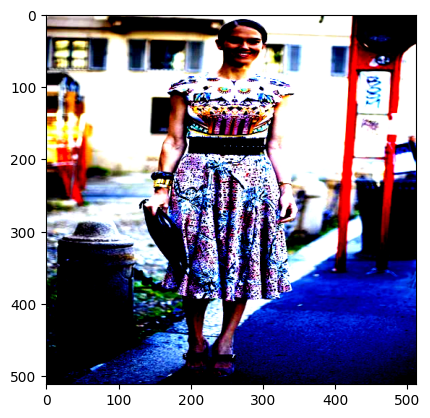

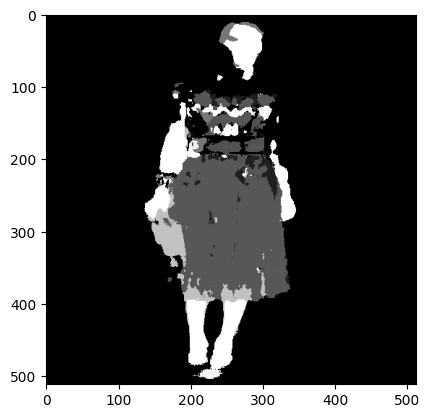

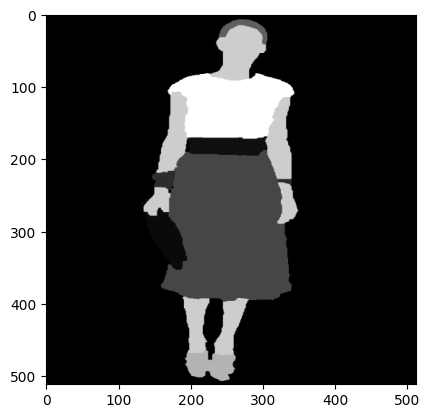

In [23]:
test_dataloader=torch.utils.data.DataLoader(test_dataset,batch_size=8,shuffle=True,collate_fn=test_dataset.collate_fn)
with torch.no_grad():
    model.eval()
    img,mask=next(iter(test_dataloader))
    _mask=model(img)
    _,_mask_m=torch.max(_mask,dim=1)
    print(_mask.shape)
    plt.imshow(img[0].detach().cpu().permute(1,2,0).numpy())
    plt.figure()
    plt.imshow(_mask_m[0].detach().cpu().numpy(),cmap='gray')
    plt.figure()
    plt.imshow(mask[0].detach().cpu().numpy(),cmap='gray')

# !!적용!!

In [24]:
example_paths = sorted(glob.glob('/kaggle/input/example-img/test_img.jpg'))
image_path = example_paths[0]
image_path

'/kaggle/input/example-img/test_img.jpg'

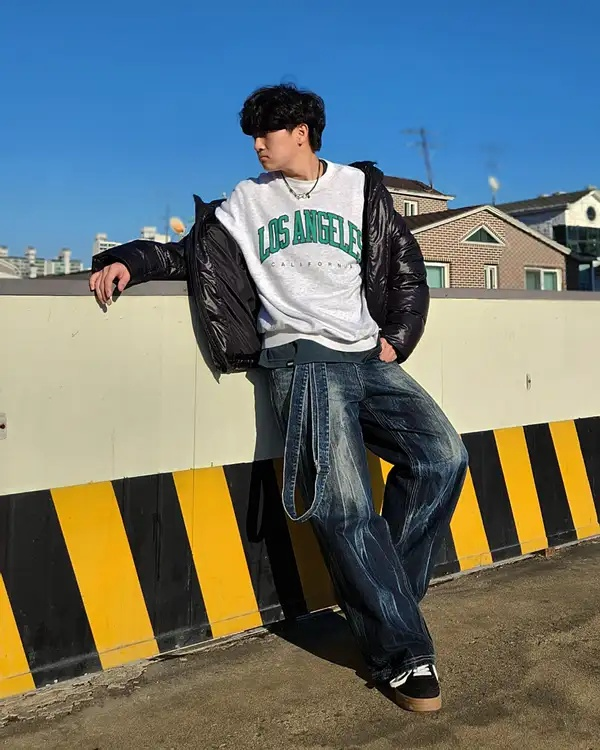

In [25]:
example_img = Image.open(image_path).convert('RGB')
example_img

In [26]:
example_img.size

(600, 750)

Output shape:
torch.Size([1, 59, 512, 512])

/tmp/ipykernel_34/4277521872.py:44: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of 381 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will give the desired result (the cast overflows).
  colored_map[i, j] = colors[class_idx]  # 색상 지정
/tmp/ipykernel_34/4277521872.py:44: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of 386 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will give the desired result (the cast overflows).
  colored_map[i, j] = colors[class_idx]  # 색상 지정
/tmp/ipykernel_34/4277521872.py:44: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of 330 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will 

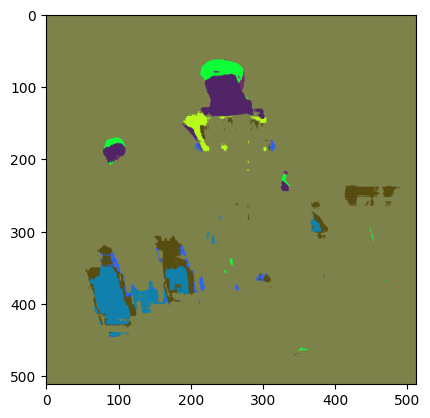

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import random
import torchvision.transforms as transforms


tfms = transforms.Compose([
    transforms.Resize((512, 512)),  # 이미지 크기를 조정합니다.
    transforms.ToTensor(),  # 이미지를 텐서로 변환합니다.
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 이미지를 정규화합니다.
])

# 이미지에 전처리를 적용합니다.
example_img_tensor = tfms(example_img).unsqueeze(0)  # 배치 차원을 추가합니다.

# GPU를 사용할 경우
if torch.cuda.is_available():
    example_img_tensor = example_img_tensor.cuda()

# 모델에 이미지를 전달하여 segmentation을 수행합니다.
with torch.no_grad():
    model.eval()
    output = model(example_img_tensor)
    print("Output shape:", output.shape)  # 출력된 텐서의 크기 출력


num_classes = 59
colors = [[random.randint(0, 511) for _ in range(3)] for _ in range(num_classes)]


# 세그멘테이션 맵을 이미지로 변환
segmentation_map = output.argmax(dim=1).cpu().numpy()  # 가장 높은 확률을 가진 클래스의 인덱스 선택


def colorize_segmentation_map(segmentation_map, colors):
    # 세그멘테이션 맵을 RGB 이미지로 변환
    num_classes = len(colors)
    height, width = segmentation_map.shape[1:]
    colored_map = np.zeros((height, width, 3), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            class_idx = segmentation_map[0, i, j]  # 각 픽셀의 클래스 인덱스
            if class_idx < num_classes:  # 클래스 인덱스가 유효한 경우에만 색상 지정
                colored_map[i, j] = colors[class_idx]  # 색상 지정
    return colored_map

# 색상을 적용한 이미지 생성
colored_image = colorize_segmentation_map(segmentation_map, colors)

# 이미지 시각화
plt.imshow(colored_image)

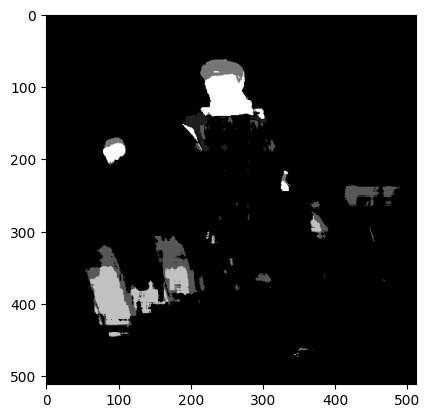

In [28]:
gray_image = np.squeeze(segmentation_map) * (255 // (num_classes - 1))

# 이미지 시각화
plt.imshow(gray_image, cmap='gray')

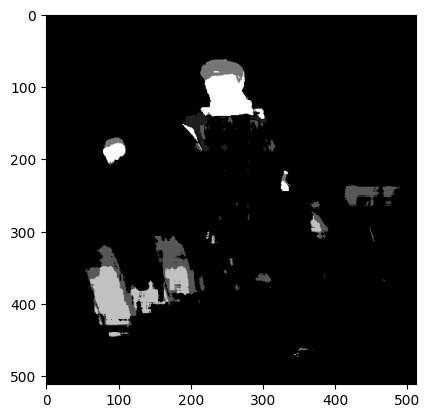

In [29]:
gray_image = np.squeeze(segmentation_map) * (255 // (num_classes - 1))

# 이미지 시각화
plt.imshow(gray_image, cmap='gray')

/tmp/ipykernel_34/4277521872.py:44: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of 308 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will give the desired result (the cast overflows).
  colored_map[i, j] = colors[class_idx]  # 색상 지정
/tmp/ipykernel_34/4277521872.py:44: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of 298 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will give the desired result (the cast overflows).
  colored_map[i, j] = colors[class_idx]  # 색상 지정
/tmp/ipykernel_34/4277521872.py:44: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of 332 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will 

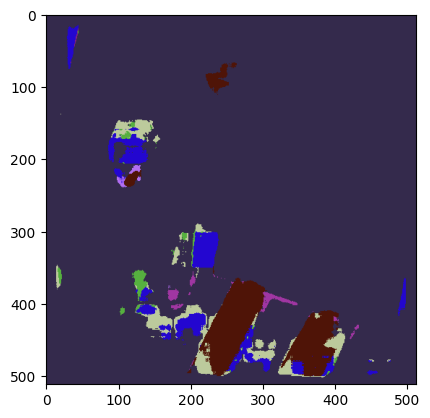

In [30]:
tfms = transforms.Compose([
    transforms.RandomResizedCrop((512, 512), scale=(0.5, 1.0)),  # 무작위 자르기 및 크기 조정
    transforms.RandomHorizontalFlip(),  # 무작위 수평 뒤집기
    transforms.RandomRotation(15),  # 무작위 회전
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 색상 변화
    transforms.ToTensor(),  # 이미지를 텐서로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 이미지를 정규화
])


# 이미지에 전처리를 적용합니다.
example_img_tensor = tfms(example_img).unsqueeze(0)  # 배치 차원을 추가합니다.

# GPU를 사용할 경우
if torch.cuda.is_available():
    example_img_tensor = example_img_tensor.cuda()

# 모델에 이미지를 전달하여 segmentation을 수행합니다.
with torch.no_grad():
    model.eval()
    output = model(example_img_tensor)
#     print("Output shape:", output.shape)  # 출력된 텐서의 크기 출력


num_classes = 59
colors = [[random.randint(0, 511) for _ in range(3)] for _ in range(num_classes)]


# 세그멘테이션 맵을 이미지로 변환
segmentation_map = output.argmax(dim=1).cpu().numpy()  # 가장 높은 확률을 가진 클래스의 인덱스 선택

# 색상을 적용한 이미지 생성
colored_image = colorize_segmentation_map(segmentation_map, colors)

# 이미지 시각화
plt.imshow(colored_image)

/tmp/ipykernel_34/4277521872.py:44: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of 465 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will give the desired result (the cast overflows).
  colored_map[i, j] = colors[class_idx]  # 색상 지정
/tmp/ipykernel_34/4277521872.py:44: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of 422 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will give the desired result (the cast overflows).
  colored_map[i, j] = colors[class_idx]  # 색상 지정
/tmp/ipykernel_34/4277521872.py:44: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of 406 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will 

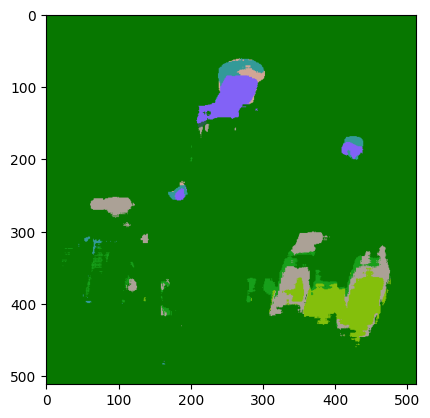

In [31]:
tfms = transforms.Compose([
    transforms.RandomResizedCrop((512, 512), scale=(0.5, 1.0)),  # 무작위 자르기 및 크기 조정
    transforms.RandomHorizontalFlip(),  # 무작위 수평 뒤집기
    transforms.RandomRotation(15),  # 무작위 회전
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 색상 변화
    transforms.ToTensor(),  # 이미지를 텐서로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 이미지를 정규화
])


# 이미지에 전처리를 적용합니다.
example_img_tensor = tfms(example_img).unsqueeze(0)  # 배치 차원을 추가합니다.

# GPU를 사용할 경우
if torch.cuda.is_available():
    example_img_tensor = example_img_tensor.cuda()

# 모델에 이미지를 전달하여 segmentation을 수행합니다.
with torch.no_grad():
    model.eval()
    output = model(example_img_tensor)
#     print("Output shape:", output.shape)  # 출력된 텐서의 크기 출력


num_classes = 59
colors = [[random.randint(0, 511) for _ in range(3)] for _ in range(num_classes)]


# 세그멘테이션 맵을 이미지로 변환
segmentation_map = output.argmax(dim=1).cpu().numpy()  # 가장 높은 확률을 가진 클래스의 인덱스 선택

# 색상을 적용한 이미지 생성
colored_image = colorize_segmentation_map(segmentation_map, colors)

# 이미지 시각화
plt.imshow(colored_image)

In [32]:
for class_idx in range(59):
    class_prob = output[0, class_idx].detach().cpu().numpy()
    print(f"Class {class_idx}: Probability = {class_prob}")

Class 0: Probability = [[6.507811  5.910831  5.800632  ... 5.6974125 5.774862  6.049495 ]
 [5.5655856 5.591666  5.4865565 ... 5.480396  5.758317  5.6355853]
 [5.419512  5.640341  5.6540127 ... 5.503237  5.917311  5.698746 ]
 ...
 [5.416276  5.5386434 5.5112104 ... 5.672867  5.8746634 5.718472 ]
 [5.3789105 5.5947294 5.501145  ... 5.663813  5.6644783 5.5817046]
 [5.892205  5.552981  5.4991198 ... 5.5304174 5.5520945 5.649026 ]]

Class 1: Probability = [[-4.08728   -3.726716  -3.6485903 ... -3.6861172 -3.8289444 -3.8945036]
 [-3.5902781 -3.7249715 -3.58822   ... -3.7889261 -4.056329  -3.7853642]
 [-3.5434277 -3.8273377 -3.851241  ... -3.9355478 -4.2963257 -3.8828032]
 ...
 [-3.6004312 -3.9477189 -3.9382532 ... -4.1615586 -4.316014  -3.9158227]
 [-3.539979  -3.8993094 -3.8851483 ... -4.038805  -4.1065063 -3.8181448]
 [-3.6802478 -3.6309354 -3.619771  ... -3.7636745 -3.7947366 -3.7740998]]

Class 2: Probability = [[-2.6243768 -2.1298962 -2.2103577 ... -2.1536708 -2.1032631 -2.3170993]
 [-1.9670371 -1.9904377 -2.0581646 ... -2.1313064 -2.0746076 -2.0142944]
 [-2.0160518 -2.0752656 -2.210804  ... -2.1658845 -2.1663208 -2.0369318]
 ...
 [-1.9593458 -2.0087433 -2.0467231 ... -2.1208732 -2.0945961 -1.9577869]
 [-1.9174036 -1.9451954 -1.9846301 ... -2.0033932 -1.9379686 -1.88056  ]
 [-2.0661836 -1.8695748 -1.8129144 ... -1.8993694 -1.8096923 -1.9774143]]

Class 3: Probability = [[-4.3747716 -3.8365936 -3.8276477 ... -3.6684666 -3.6937466 -3.8727052]
 [-3.7579377 -3.61321   -3.5750067 ... -3.520397  -3.6617649 -3.6034715]
 [-3.5453675 -3.6372812 -3.6838634 ... -3.5550134 -3.8252373 -3.703519 ]
 ...
 [-3.536059  -3.6355245 -3.6445832 ... -3.7865317 -3.90827   -3.7354174]
 [-3.508654  -3.623146  -3.5860593 ... -3.7072425 -3.7118702 -3.680337 ]
 [-3.9243019 -3.6490479 -3.6344385 ... -3.6273327 -3.6414933 -3.749789 ]]

Class 4: Probability = [[-2.844724  -2.4183564 -2.386991  ... -2.235719  -2.1933486 -2.4878192]
 [-2.3662126 -2.323792  -2.2942977 ... -2.2700918 -2.270842  -2.2421327]
 [-2.3319995 -2.4270265 -2.5016654 ... -2.391117  -2.442464  -2.2403464]
 ...
 [-2.3395011 -2.4230204 -2.4848197 ... -2.477552  -2.3863418 -2.2280061]
 [-2.2395    -2.3687437 -2.39464   ... -2.3420227 -2.2030082 -2.0818918]
 [-2.3692267 -2.1820157 -2.2202654 ... -2.1958501 -2.1173456 -2.150536 ]]

...

Class 54: Probability = [[-4.551005  -3.947055  -3.839409  ... -3.7400196 -3.8212998 -4.1586394]
 [-4.0091767 -3.7482052 -3.6036985 ... -3.635276  -3.8232403 -3.847903 ]
 [-3.8633106 -3.795561  -3.7941408 ... -3.6795714 -4.0156946 -3.9139693]
 ...
 [-3.8158872 -3.7137885 -3.5933943 ... -3.7596679 -3.93152   -3.8984737]
 [-3.791194  -3.7587726 -3.6303785 ... -3.721576  -3.8080924 -3.8210177]
 [-4.3140492 -3.8203654 -3.7813056 ... -3.7400188 -3.8268309 -3.885731 ]]

Class 55: Probability = [[-4.328442  -3.9806323 -3.8859332 ... -3.7744255 -3.822537  -3.815853 ]
 [-3.8007164 -3.752969  -3.697983  ... -3.7950563 -3.9535797 -3.7102594]
 [-3.6936214 -3.8016675 -3.8985488 ... -3.8935497 -4.107079  -3.7044406]
 ...
 [-3.548123  -3.6919172 -3.7341938 ... -3.9321039 -3.9856591 -3.6595192]
 [-3.520837  -3.623481  -3.6112802 ... -3.7324455 -3.7086313 -3.4678223]
 [-3.693164  -3.4397566 -3.3933692 ... -3.473595  -3.4258938 -3.4690912]]

Class 56: Probability = [[-5.469987  -4.826631  -4.667231  ... -4.4687552 -4.6427364 -4.9113193]
 [-4.5749745 -4.3817477 -4.1282115 ... -4.019032  -4.424357  -4.5155697]
 [-4.3669076 -4.301543  -4.203109  ... -3.971957  -4.556602  -4.5044336]
 ...
 [-4.360934  -4.3034234 -4.102548  ... -4.3008413 -4.68432   -4.6122193]
 [-4.4548345 -4.5154576 -4.294279  ... -4.399381  -4.647731  -4.6280274]
 [-5.128538  -4.801997  -4.643331  ... -4.6084456 -4.7360835 -4.8530436]]

Class 57: Probability = [[-5.814802  -5.345256  -5.087768  ... -5.0185647 -5.1773853 -5.3169   ]
 [-5.0857024 -5.006074  -4.791944  ... -4.709881  -5.151358  -5.017867 ]
 [-4.823384  -4.950805  -4.7854934 ... -4.7019553 -5.333243  -5.046908 ]
 ...
 [-4.787494  -4.848671  -4.7368026 ... -4.9622755 -5.360872  -5.1511745]
 [-4.8566747 -5.0297027 -4.7624235 ... -4.968177  -5.195898  -5.1307807]
 [-5.373315  -5.156967  -5.017738  ... -4.9832034 -5.151366  -5.203552 ]]

Class 58: Probability = [[-5.888809  -5.2039    -4.9105644 ... -4.8364735 -5.055404  -5.358029 ]
 [-5.0052214 -4.837007  -4.5651646 ... -4.431265  -4.9494367 -4.9669547]
 [-4.6930904 -4.743655  -4.4878626 ... -4.3824086 -5.0842195 -5.023398 ]
 ...
 [-4.739078  -4.646415  -4.4360795 ... -4.6333776 -5.155351  -5.0798564]
 [-4.750957  -4.866306  -4.5274796 ... -4.757885  -5.0714445 -5.1500163]
 [-5.438001  -5.116101  -4.9865794 ... -4.9470243 -5.205782  -5.2183366]]